In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import os

print("Files available:")
print(os.listdir("/content"))


Files available:
['.config', 'archive.zip', 'sample_data']


In [ ]:
import zipfile
import os

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")
print(os.listdir('/content/dataset'))

Dataset extracted successfully!
['retail_sales_dataset.csv']


In [ ]:
df = pd.read_csv('/content/dataset/retail_sales_dataset.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset loaded successfully!
Shape: (120000, 17)

Columns:
['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'payment_method', 'sales_channel', 'region']


,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [ ]:
print(df.columns.tolist())

['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'payment_method', 'sales_channel', 'region']


In [ ]:
for i, col in enumerate(df.columns, 1):
    print(i, ":", col)

1 : transaction_id
2 : transaction_date
3 : customer_id
4 : customer_gender
5 : customer_age_group
6 : customer_segment
7 : product_id
8 : product_name
9 : category
10 : brand
11 : quantity
12 : unit_price
13 : discount_pct
14 : sales_amount
15 : payment_method
16 : sales_channel
17 : region


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64


In [ ]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


In [ ]:
# Convert transaction date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create customer-level RFM features
reference_date = df['transaction_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('transaction_date', lambda x: (reference_date - x.max()).days),
    Frequency=('transaction_id', 'count'),
    Monetary=('sales_amount', 'sum')
).reset_index()

print("RFM analysis completed successfully!")
display(rfm.head())

RFM analysis completed successfully!


,customer_id,Recency,Frequency,Monetary
0,C000001,73,4,1401.11
1,C000002,33,6,1330.54
2,C000003,311,4,1349.69
3,C000004,121,4,2597.00
4,C000005,119,3,720.48


In [ ]:
# Select RFM features for clustering
features = ['Recency', 'Frequency', 'Monetary']

X = rfm[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("RFM features standardized successfully!")
print("Shape:", X_scaled.shape)

RFM features standardized successfully!
Shape: (24784, 3)


In [ ]:
# Select RFM features
features = ['Recency', 'Frequency', 'Monetary']

x = rfm[features]

# Standardize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("RFM features standardized successfully!")
print("Shape:", x_scaled.shape)

RFM features standardized successfully!
Shape: (24784, 3)


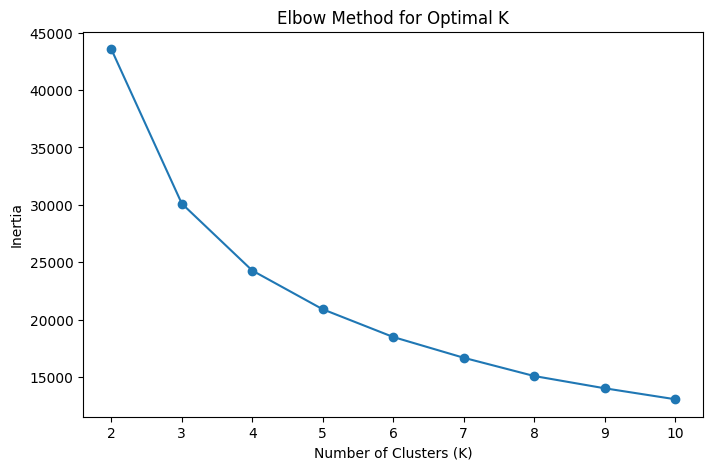

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [ ]:
# Apply K-Means clustering with 5 clusters

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(x_scaled)

print("K-Means clustering completed successfully!")
print("\nNumber of customers in each cluster:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means clustering completed successfully!

Number of customers in each cluster:
Cluster
0    3677
1    3560
2    2720
3    7233
4    7594
Name: count, dtype: int64


In [ ]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

display(cluster_summary)

,Recency,Frequency,Monetary
Cluster,,,
0,255.595594,4.719336,1919.161384
1,79.129494,8.085112,3749.135649
2,424.250000,2.295221,748.977699
3,100.958800,3.222176,955.820983
4,65.634975,5.835528,2107.282410


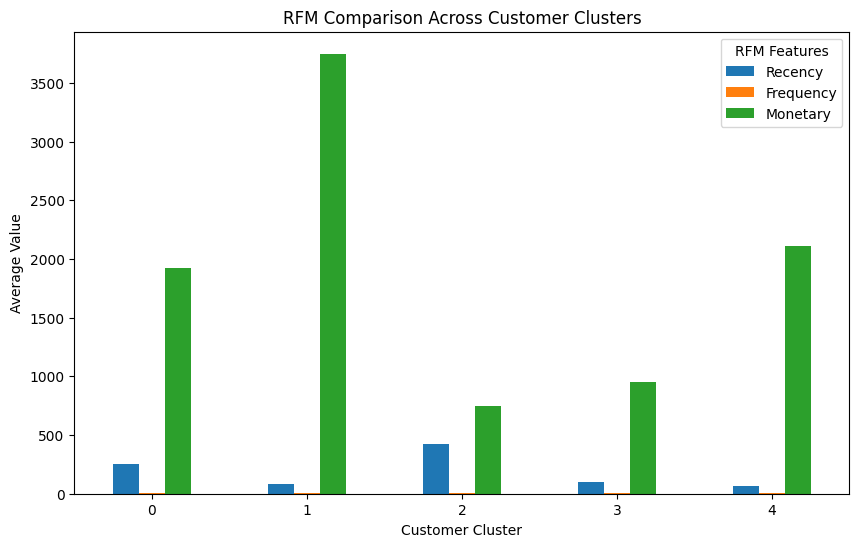

In [ ]:
import matplotlib.pyplot as plt

# RFM values for each cluster
cluster_summary[['Recency', 'Frequency', 'Monetary']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("RFM Comparison Across Customer Clusters")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="RFM Features")
plt.show()

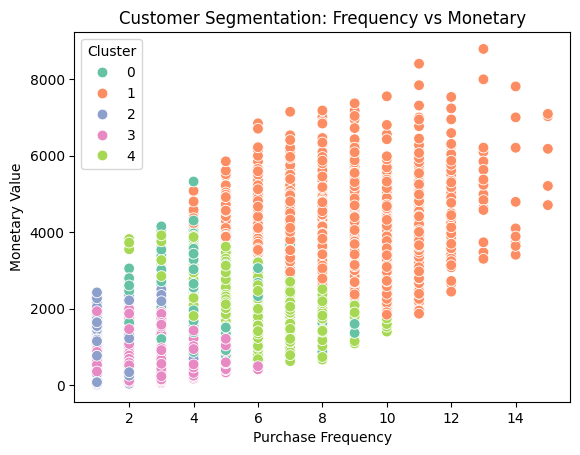

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.show()

In [ ]:
# Create final customer segmentation summary

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary['Customer_Count'] = rfm['Cluster'].value_counts().sort_index()

cluster_summary = cluster_summary[
    ['Customer_Count', 'Recency', 'Frequency', 'Monetary']
]

display(cluster_summary.round(2))

,Customer_Count,Recency,Frequency,Monetary
Cluster,,,,
0,3677,255.60,4.72,1919.16
1,3560,79.13,8.09,3749.14
2,2720,424.25,2.30,748.98
3,7233,100.96,3.22,955.82
4,7594,65.63,5.84,2107.28


In [ ]:
# Create final customer segmentation summary

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary['Customer_Count'] = rfm['Cluster'].value_counts().sort_index()

cluster_summary = cluster_summary[
    ['Customer_Count', 'Recency', 'Frequency', 'Monetary']
]

display(cluster_summary.round(2))

,Customer_Count,Recency,Frequency,Monetary
Cluster,,,,
0,3677,255.60,4.72,1919.16
1,3560,79.13,8.09,3749.14
2,2720,424.25,2.30,748.98
3,7233,100.96,3.22,955.82
4,7594,65.63,5.84,2107.28


In [ ]:
segment_names = {
    0: 'Regular Customers',
    1: 'High Value Customers',
    2: 'Lost Customers',
    3: 'Occasional Customers',
    4: 'Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

In [ ]:
print("Number of customers in each segment:")
print(rfm['Segment'].value_counts())

Number of customers in each segment:
Segment
Loyal Customers         7594
Occasional Customers    7233
Regular Customers       3677
High Value Customers    3560
Lost Customers          2720
Name: count, dtype: int64


In [ ]:

segment_summary = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

segment_summary['Customer_Count'] = rfm['Segment'].value_counts()

segment_summary = segment_summary[
    ['Customer_Count', 'Recency', 'Frequency', 'Monetary']
]

display(segment_summary.round(2))

,Customer_Count,Recency,Frequency,Monetary
Segment,,,,
High Value Customers,3560,79.13,8.09,3749.14
Lost Customers,2720,424.25,2.30,748.98
Loyal Customers,7594,65.63,5.84,2107.28
Occasional Customers,7233,100.96,3.22,955.82
Regular Customers,3677,255.60,4.72,1919.16


In [ ]:
strategy = {
    'High Value Customers': 'VIP offers, exclusive discounts and premium rewards',
    'Loyal Customers': 'Loyalty programs and personalized offers',
    'Regular Customers': 'Personalized promotions to increase purchase frequency',
    'Occasional Customers': 'Coupons and offers to encourage repeat purchases',
    'Lost Customers': 'Reactivation campaigns and special comeback discounts'
}

for segment, action in strategy.items():
    print(f"{segment}: {action}")

High Value Customers: VIP offers, exclusive discounts and premium rewards
Loyal Customers: Loyalty programs and personalized offers
Regular Customers: Personalized promotions to increase purchase frequency
Occasional Customers: Coupons and offers to encourage repeat purchases
Lost Customers: Reactivation campaigns and special comeback discounts


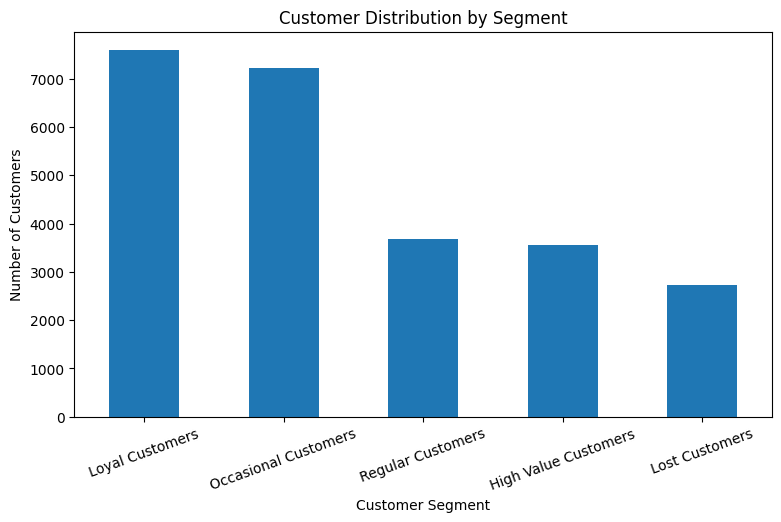

In [ ]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(9,5))
segment_counts.plot(kind='bar')

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

<Figure size 900x500 with 0 Axes>

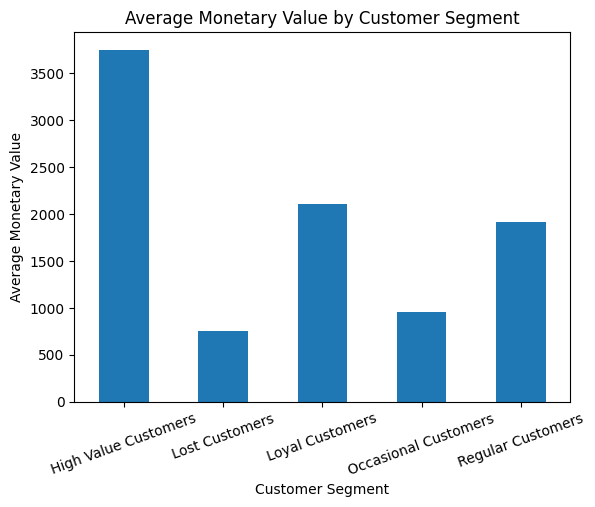

In [ ]:
# Convert Segment index into a normal column
segment_summary_plot = segment_summary.reset_index()

plt.figure(figsize=(9, 5))

segment_summary_plot.plot(
    x='Segment',
    y='Monetary',
    kind='bar',
    legend=False
)

plt.title("Average Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")
plt.xticks(rotation=20)
plt.show()

In [ ]:
# Final Customer Segment Analysis

final_summary = segment_summary_plot.copy()

final_summary['Strategy'] = final_summary['Segment'].map({
    'High Value Customers': 'VIP offers, exclusive discounts and premium rewards',
    'Loyal Customers': 'Loyalty programs and personalized offers',
    'Regular Customers': 'Personalized promotions to increase purchase frequency',
    'Occasional Customers': 'Coupons and offers to encourage repeat purchases',
    'Lost Customers': 'Reactivation campaigns and special comeback discounts'
})

display(final_summary.round(2))

,Segment,Customer_Count,Recency,Frequency,Monetary,Strategy
0,High Value Customers,3560,79.13,8.09,3749.14,"VIP offers, exclusive discounts and premium re..."
1,Lost Customers,2720,424.25,2.30,748.98,Reactivation campaigns and special comeback di...
2,Loyal Customers,7594,65.63,5.84,2107.28,Loyalty programs and personalized offers
3,Occasional Customers,7233,100.96,3.22,955.82,Coupons and offers to encourage repeat purchases
4,Regular Customers,3677,255.60,4.72,1919.16,Personalized promotions to increase purchase f...


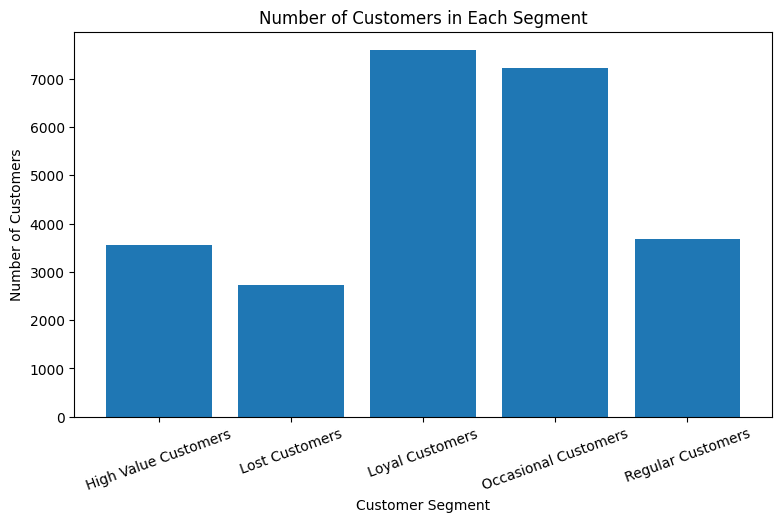

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    final_summary['Segment'],
    final_summary['Customer_Count']
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

<Figure size 900x500 with 0 Axes>

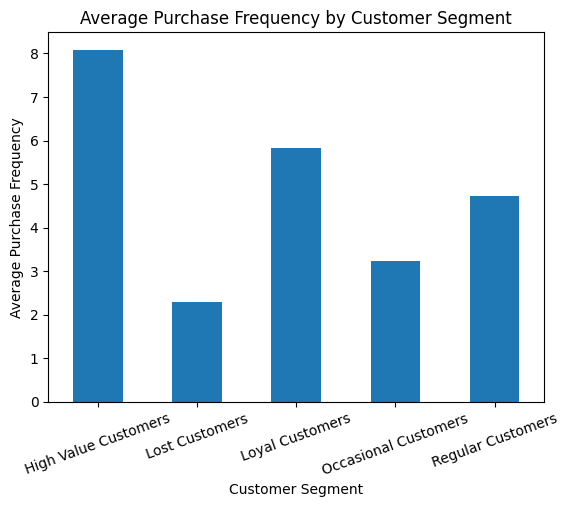

In [ ]:
# Convert Segment index into a column
segment_summary_plot = segment_summary.reset_index()

plt.figure(figsize=(9,5))

segment_summary_plot.plot(
    x='Segment',
    y='Frequency',
    kind='bar',
    legend=False
)

plt.title("Average Purchase Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Purchase Frequency")
plt.xticks(rotation=20)
plt.show()

<Figure size 900x500 with 0 Axes>

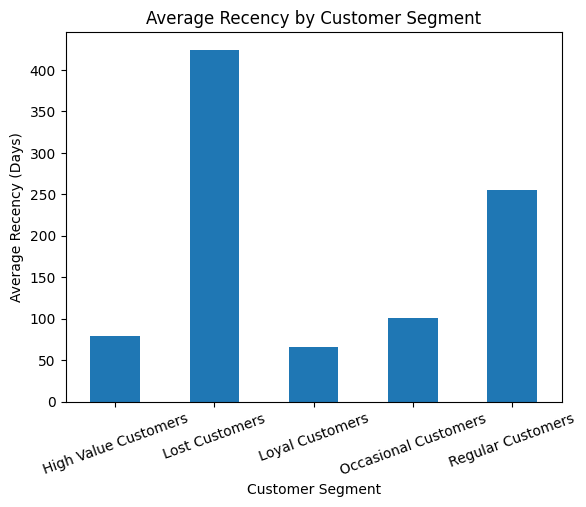

In [ ]:
plt.figure(figsize=(9,5))

segment_summary_plot.plot(
    x='Segment',
    y='Recency',
    kind='bar',
    legend=False
)

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (Days)")
plt.xticks(rotation=20)
plt.show()

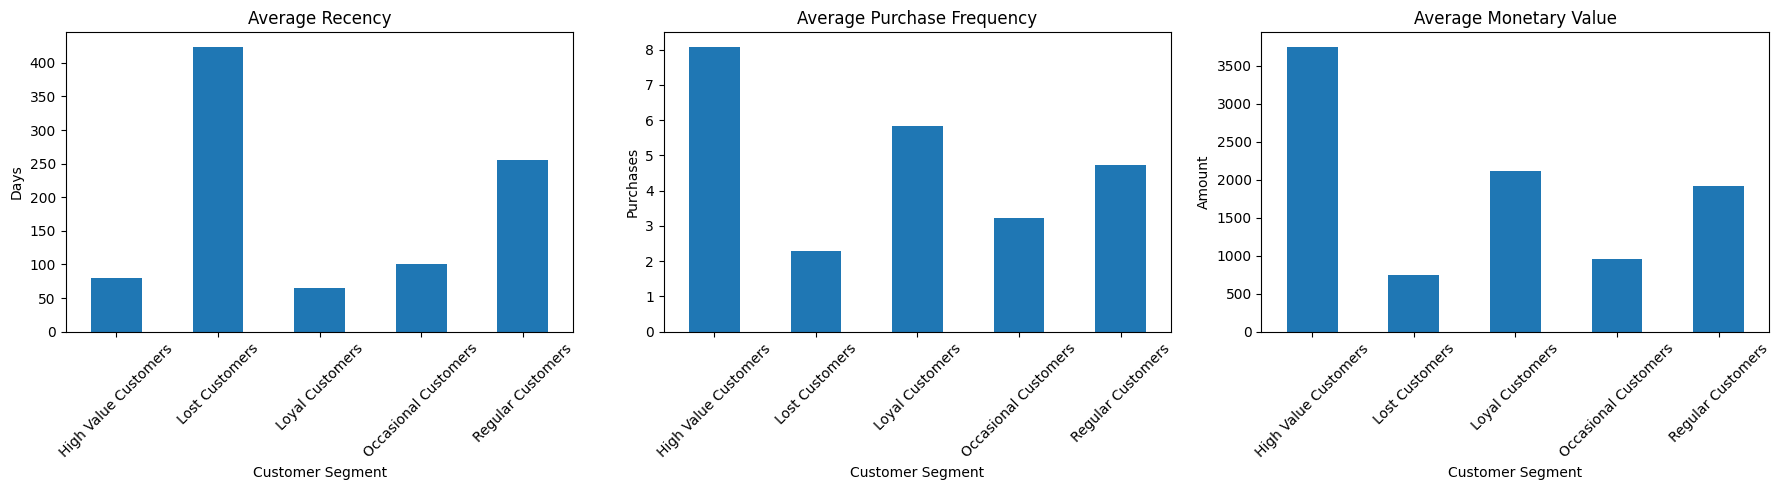

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
segment_summary_plot.plot(
    x='Segment',
    y='Recency',
    kind='bar',
    ax=axes[0],
    legend=False
)
axes[0].set_title("Average Recency")
axes[0].set_xlabel("Customer Segment")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis='x', rotation=45)

# Frequency
segment_summary_plot.plot(
    x='Segment',
    y='Frequency',
    kind='bar',
    ax=axes[1],
    legend=False
)
axes[1].set_title("Average Purchase Frequency")
axes[1].set_xlabel("Customer Segment")
axes[1].set_ylabel("Purchases")
axes[1].tick_params(axis='x', rotation=45)

# Monetary
segment_summary_plot.plot(
    x='Segment',
    y='Monetary',
    kind='bar',
    ax=axes[2],
    legend=False
)
axes[2].set_title("Average Monetary Value")
axes[2].set_xlabel("Customer Segment")
axes[2].set_ylabel("Amount")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

KeyError: 'Segment'

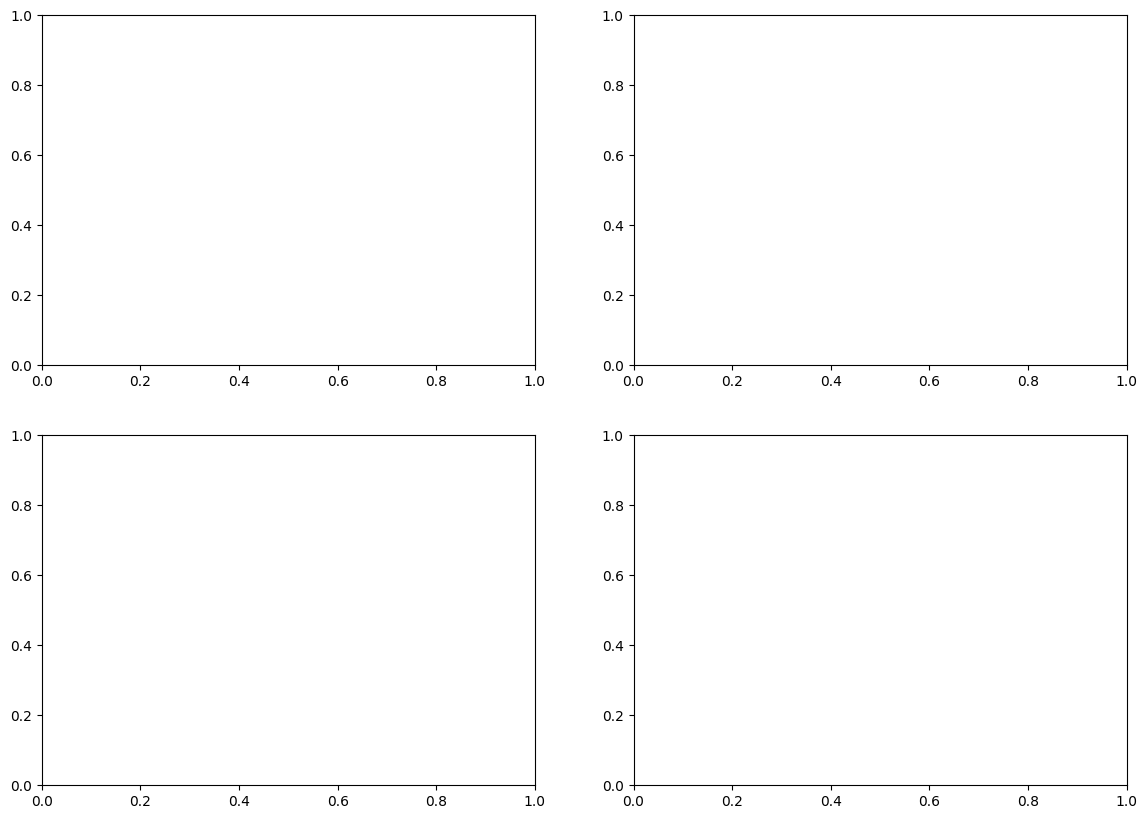

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Number of Customers
segment_summary.plot(
    x='Segment',
    y='Customer_Count',
    kind='bar',
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_title('Number of Customers by Segment')
axes[0, 0].set_xlabel('Customer Segment')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].tick_params(axis='x', rotation=30)

# 2. Average Recency
segment_summary.plot(
    x='Segment',
    y='Recency',
    kind='bar',
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_title('Average Recency by Segment')
axes[0, 1].set_xlabel('Customer Segment')
axes[0, 1].set_ylabel('Average Recency (Days)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Average Frequency
segment_summary.plot(
    x='Segment',
    y='Frequency',
    kind='bar',
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title('Average Purchase Frequency by Segment')
axes[1, 0].set_xlabel('Customer Segment')
axes[1, 0].set_ylabel('Average Purchase Frequency')
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Average Monetary Value
segment_summary.plot(
    x='Segment',
    y='Monetary',
    kind='bar',
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_title('Average Monetary Value by Segment')
axes[1, 1].set_xlabel('Customer Segment')
axes[1, 1].set_ylabel('Average Monetary Value')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('RFM Customer Segmentation Dashboard', fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
# Convert Segment from index into a normal column
segment_summary = segment_summary.reset_index()

# Check the column names
print(segment_summary.columns)

Index(['Segment', 'Customer_Count', 'Recency', 'Frequency', 'Monetary'], dtype='object')


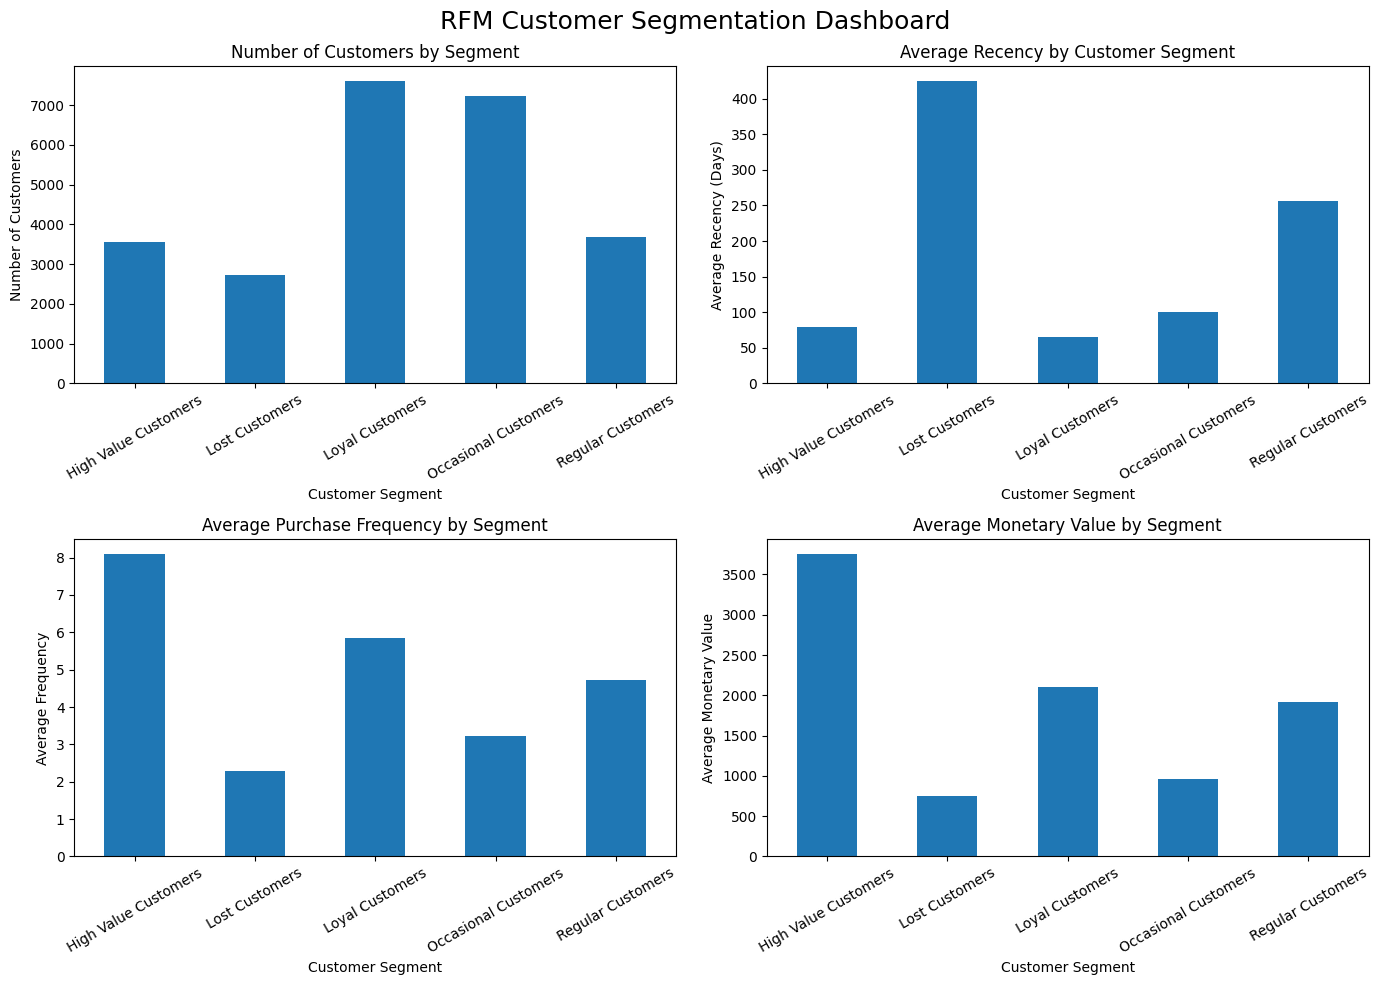

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Customer Count
segment_summary.plot(
    x='Segment',
    y='Customer_Count',
    kind='bar',
    ax=axes[0,0],
    legend=False
)
axes[0,0].set_title('Number of Customers by Segment')
axes[0,0].set_xlabel('Customer Segment')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=30)

# Recency
segment_summary.plot(
    x='Segment',
    y='Recency',
    kind='bar',
    ax=axes[0,1],
    legend=False
)
axes[0,1].set_title('Average Recency by Customer Segment')
axes[0,1].set_xlabel('Customer Segment')
axes[0,1].set_ylabel('Average Recency (Days)')
axes[0,1].tick_params(axis='x', rotation=30)

# Frequency
segment_summary.plot(
    x='Segment',
    y='Frequency',
    kind='bar',
    ax=axes[1,0],
    legend=False
)
axes[1,0].set_title('Average Purchase Frequency by Segment')
axes[1,0].set_xlabel('Customer Segment')
axes[1,0].set_ylabel('Average Frequency')
axes[1,0].tick_params(axis='x', rotation=30)

# Monetary
segment_summary.plot(
    x='Segment',
    y='Monetary',
    kind='bar',
    ax=axes[1,1],
    legend=False
)
axes[1,1].set_title('Average Monetary Value by Segment')
axes[1,1].set_xlabel('Customer Segment')
axes[1,1].set_ylabel('Average Monetary Value')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('RFM Customer Segmentation Dashboard', fontsize=18)
plt.tight_layout()
plt.show()

KEY BUSINESS INSIGHTS

• Loyal Customers are the largest customer segment with 7,594 customers, indicating a strong base of repeat customers.

• High Value Customers have the highest average monetary value of 3,749.14 and the highest purchase frequency of 8.09, making them the most valuable customer segment.

• Lost Customers have the highest average recency of 424.25 days and a low purchase frequency of 2.30, indicating that these customers have been inactive for a long period.

• Occasional Customers have relatively low purchase frequency and monetary value, showing an opportunity to encourage them to purchase more frequently.

• Regular Customers have a reasonable monetary value of 1,919.16, but their average recency of 255.60 days suggests that they should be engaged to prevent them from becoming inactive.

MARKETING RECOMMENDATIONS

High Value Customers:
Provide VIP offers, exclusive discounts, premium rewards and personalized services.

Loyal Customers:
Introduce loyalty programs, personalized offers and reward points to maintain their engagement.

Regular Customers:
Use personalized promotions and product recommendations to increase their purchase frequency.

Occasional Customers:
Offer coupons, limited-time discounts and special offers to encourage repeat purchases.

Lost Customers:
Launch reactivation campaigns, comeback discounts and personalized messages to bring inactive customers back.

CONCLUSION

The RFM analysis successfully segmented customers based on their purchasing behaviour using Recency, Frequency and Monetary Value. The segmentation helps identify valuable, loyal, regular, occasional and lost customers. Based on these segments, targeted marketing strategies can be designed to improve customer retention, increase purchase frequency and maximize customer value.

PROJECT SUMMARY

This project uses RFM (Recency, Frequency and Monetary) analysis to segment customers according to their purchasing behaviour. Customers were grouped into five segments: High Value, Loyal, Regular, Occasional and Lost Customers.

The analysis helps identify high-value and loyal customers who contribute significantly to business revenue, while also identifying inactive customers who may require reactivation campaigns.

The resulting customer segments can be used by businesses to create targeted marketing strategies, improve customer retention, increase purchase frequency and maximize customer lifetime value.

TOOLS & TECHNOLOGIES

• Python
• Google Colab
• Pandas
• NumPy
• Matplotlib
• Seaborn
• RFM Analysis
• Data Visualization